In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data = pd.read_csv('/home/kvasonaft/Learning/spectra/data.csv', index_col = 0)

In [3]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 2, random_state = 7)
kmeans.fit(data)
data['cluster'] = kmeans.labels_

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

pca = PCA(n_components = 2)
data_pca = pca.fit_transform(data_scaled)

pca_df = pd.DataFrame(data_pca, columns = ['PC1', 'PC2'], index = data.index)

pca_df['cluster'] = kmeans.labels_

<function matplotlib.pyplot.show(close=None, block=None)>

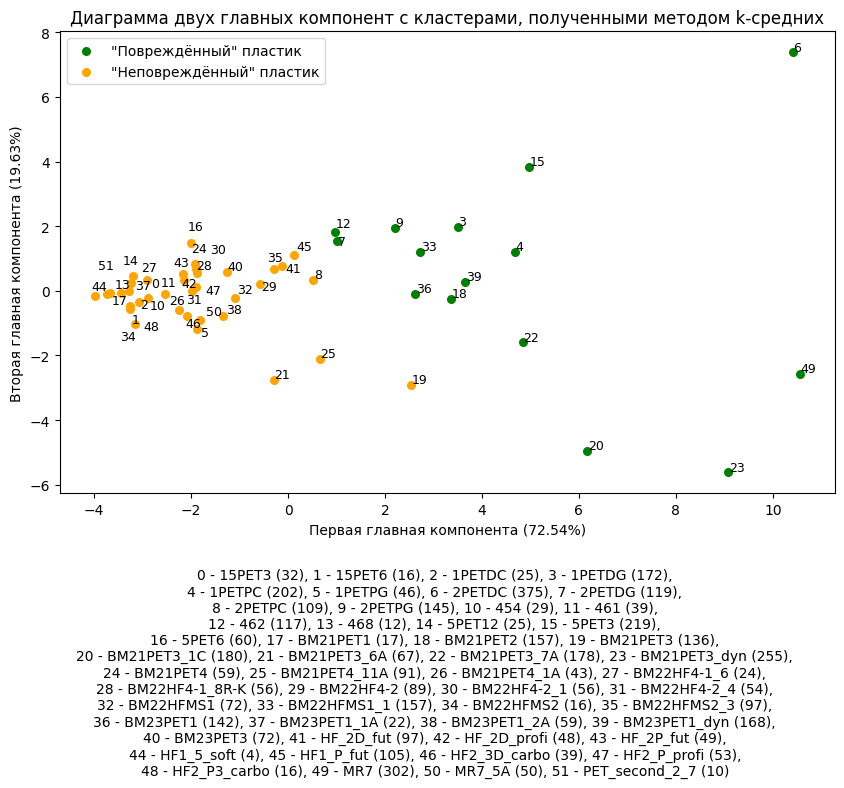

In [6]:
from adjustText import adjust_text

texts = []
colors = ['green', 'orange']
label = ['"Повреждённый" пластик', '"Неповреждённый" пластик']


fig, ax = plt.subplots(figsize=(10, 6))

for cluster in [0, 1]:
    ax.scatter(pca_df[pca_df['cluster'] == cluster]['PC1'],
                pca_df[pca_df['cluster'] == cluster]['PC2'], color = colors[cluster],
                label = label[cluster], s = 30)

for i, (name, row) in enumerate(pca_df.iterrows()):
    texts.append(
        ax.text(row['PC1'], row['PC2'], str(i), fontsize=9)
    )

adjust_text(texts)

mapping_df = pd.DataFrame({'№': range(len(pca_df)),
              'Название культуры': data.index})

textblock = '0 - 15PET3 (32), 1 - 15PET6 (16), 2 - 1PETDC (25), 3 - 1PETDG (172),\n4 - 1PETPC (202), 5 - 1PETPG (46), 6 - 2PETDC (375), 7 - 2PETDG (119),\n8 - 2PETPC (109), 9 - 2PETPG (145), 10 - 454 (29), 11 - 461 (39),\n12 - 462 (117), 13 - 468 (12), 14 - 5PET12 (25), 15 - 5PET3 (219),\n16 - 5PET6 (60), 17 - BM21PET1 (17), 18 - BM21PET2 (157), 19 - BM21PET3 (136),\n20 - BM21PET3_1C (180), 21 - BM21PET3_6A (67), 22 - BM21PET3_7A (178), 23 - BM21PET3_dyn (255),\n24 - BM21PET4 (59), 25 - BM21PET4_11A (91), 26 - BM21PET4_1A (43), 27 - BM22HF4-1_6 (24),\n28 - BM22HF4-1_8R-K (56), 29 - BM22HF4-2 (89), 30 - BM22HF4-2_1 (56), 31 - BM22HF4-2_4 (54),\n32 - BM22HFMS1 (72), 33 - BM22HFMS1_1 (157), 34 - BM22HFMS2 (16), 35 - BM22HFMS2_3 (97),\n36 - BM23PET1 (142), 37 - BM23PET1_1A (22), 38 - BM23PET1_2A (59), 39 - BM23PET1_dyn (168),\n40 - BM23PET3 (72), 41 - HF_2D_fut (97), 42 - HF_2D_profi (48), 43 - HF_2P_fut (49),\n44 - HF1_5_soft (4), 45 - HF1_P_fut (105), 46 - HF2_3D_carbo (39), 47 - HF2_P_profi (53),\n48 - HF2_P3_carbo (16), 49 - MR7 (302), 50 - MR7_5A (50), 51 - PET_second_2_7 (10)'

fig.text(0.5, -0.015, textblock, ha='center', va='top', fontsize=10, wrap=True)

plt.title('Диаграмма двух главных компонент с кластерами, полученными методом k-средних')
plt.xlabel(f'Первая главная компонента ({pca.explained_variance_ratio_[0] * 100:.2f}%)')
plt.ylabel(f'Вторая главная компонента ({pca.explained_variance_ratio_[1] * 100:.2f}%)')
plt.legend()
plt.savefig('/home/kvasonaft/Learning/spectra/pca_graph.png', dpi = 600, bbox_inches = 'tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

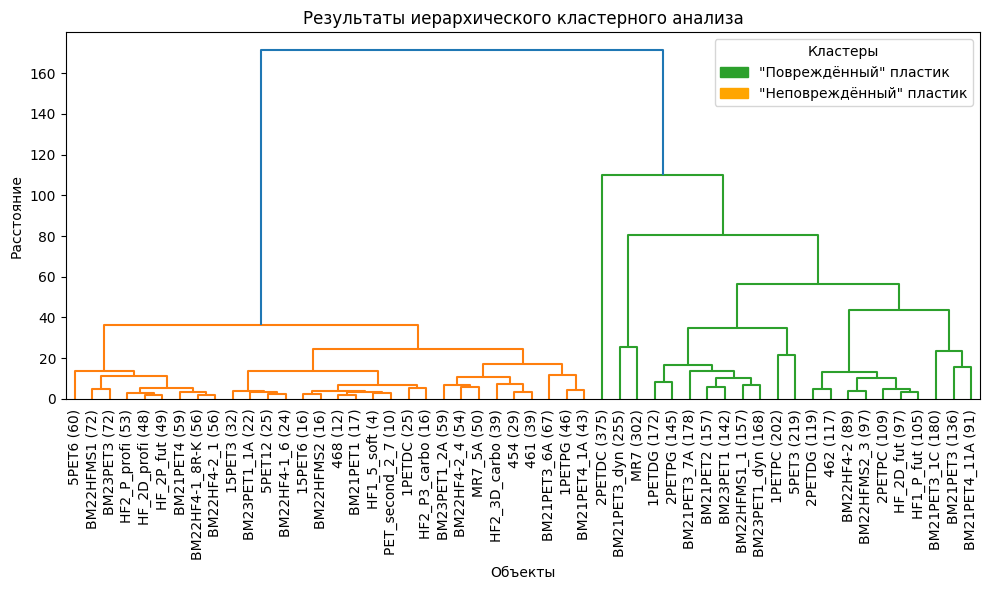

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Patch

linked = linkage(data, method = 'ward', metric = 'euclidean')

plt.figure(figsize = (10, 6))

dendrogram(linked, labels = data.index.to_list(), leaf_rotation = 90, leaf_font_size = 10, color_threshold = 150)

green = '#2ca02c'

color = [green, 'orange']
numbers = [0, 1]
legend_handles = []

for i in numbers:
    legend_handles.append(Patch(color=color[i], label = label[i]))

plt.legend(handles=legend_handles, title="Кластеры", loc='upper right')

plt.title('Результаты иерархического кластерного анализа')
plt.xlabel('Объекты')
plt.ylabel('Расстояние')
plt.tight_layout()
plt.savefig('/home/kvasonaft/Learning/spectra/dendrogram.png', dpi = 600, bbox_inches = 'tight')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

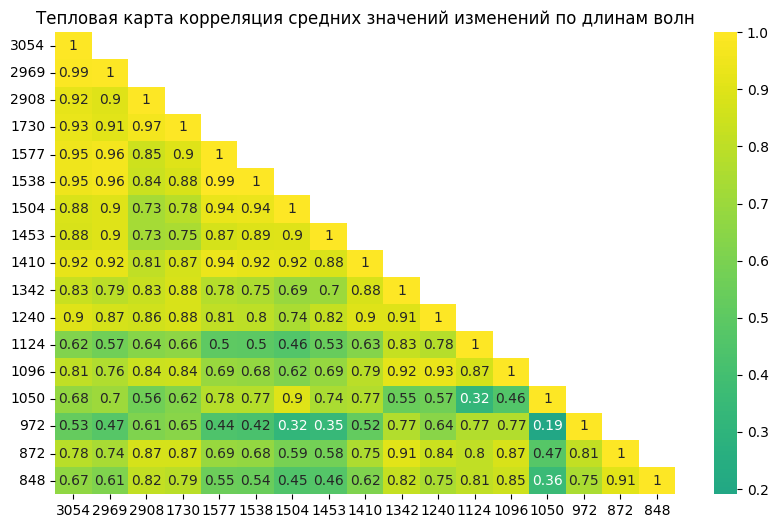

In [23]:
correlation = pd.read_csv('correlation.csv', index_col = 0)

import seaborn as sns

mask = np.triu(np.ones_like(correlation, dtype=bool), k = +1)

plt.figure(figsize = (10, 6))
sns.heatmap(correlation, mask = mask, annot = True, cmap = 'viridis', center = 0)

plt.title('Тепловая карта корреляция средних значений изменений по длинам волн')
plt.savefig('/home/kvasonaft/Learning/spectra/heatmap.png', dpi = 600, bbox_inches = 'tight')
plt.show